In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [11]:

# Assuming 'income-data.csv' is in your directory
df_raw = pd.read_csv('income-dataset.csv')
print(f"Dataset Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

Dataset Loaded: 48842 rows, 15 columns


In [12]:
def clean_income_data(df):
    df = df.drop_duplicates()
    
    # Standardize target variable
    df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
    
    # Handle missing values
    df = df.replace(['?', ' ?'], 'Unknown')
    
    # Whitespace stripping for all categories
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip()
        
    return df

df_cleaned = clean_income_data(df_raw)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11136\45856755.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)


In [13]:
def engineer_money_drivers(df):
    # Life-cycle mapping
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 45, 65, 100], 
                            labels=['Young', 'Adult', 'Senior', 'Elderly'])
    
    # Labor intensity mapping
    df['work_intensity'] = pd.cut(df['hours-per-week'], bins=[0, 34, 40, 60, 100], 
                                 labels=['Part-time', 'Full-time', 'Overtime', 'Extreme'])
    
    # Intellectual leverage mapping
    edu_map = {
        'Bachelors': 'High', 'Masters': 'High', 'Doctorate': 'High', 'Prof-school': 'High',
        'Assoc-voc': 'Medium', 'Assoc-acdm': 'Medium', 'Some-college': 'Medium'
    }
    df['education_tier'] = df['education'].map(edu_map).fillna('Basic/HS')
    
    # Target Variable: 1 for >50K, 0 for <=50K
    df['is_high_income'] = (df['income'] == '>50K').astype(int)
    
    return df

df_final = engineer_money_drivers(df_cleaned)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11136\3642202589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], x='education_tier', y='is_high_income', data=df_final, palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_11136\3642202589.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hustle = df_final.groupby('work_intensity')['is_high_income'].mean()
C:\Users\DELL\AppData\Local\Temp\ipykernel_11136\3642202589.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2,0]

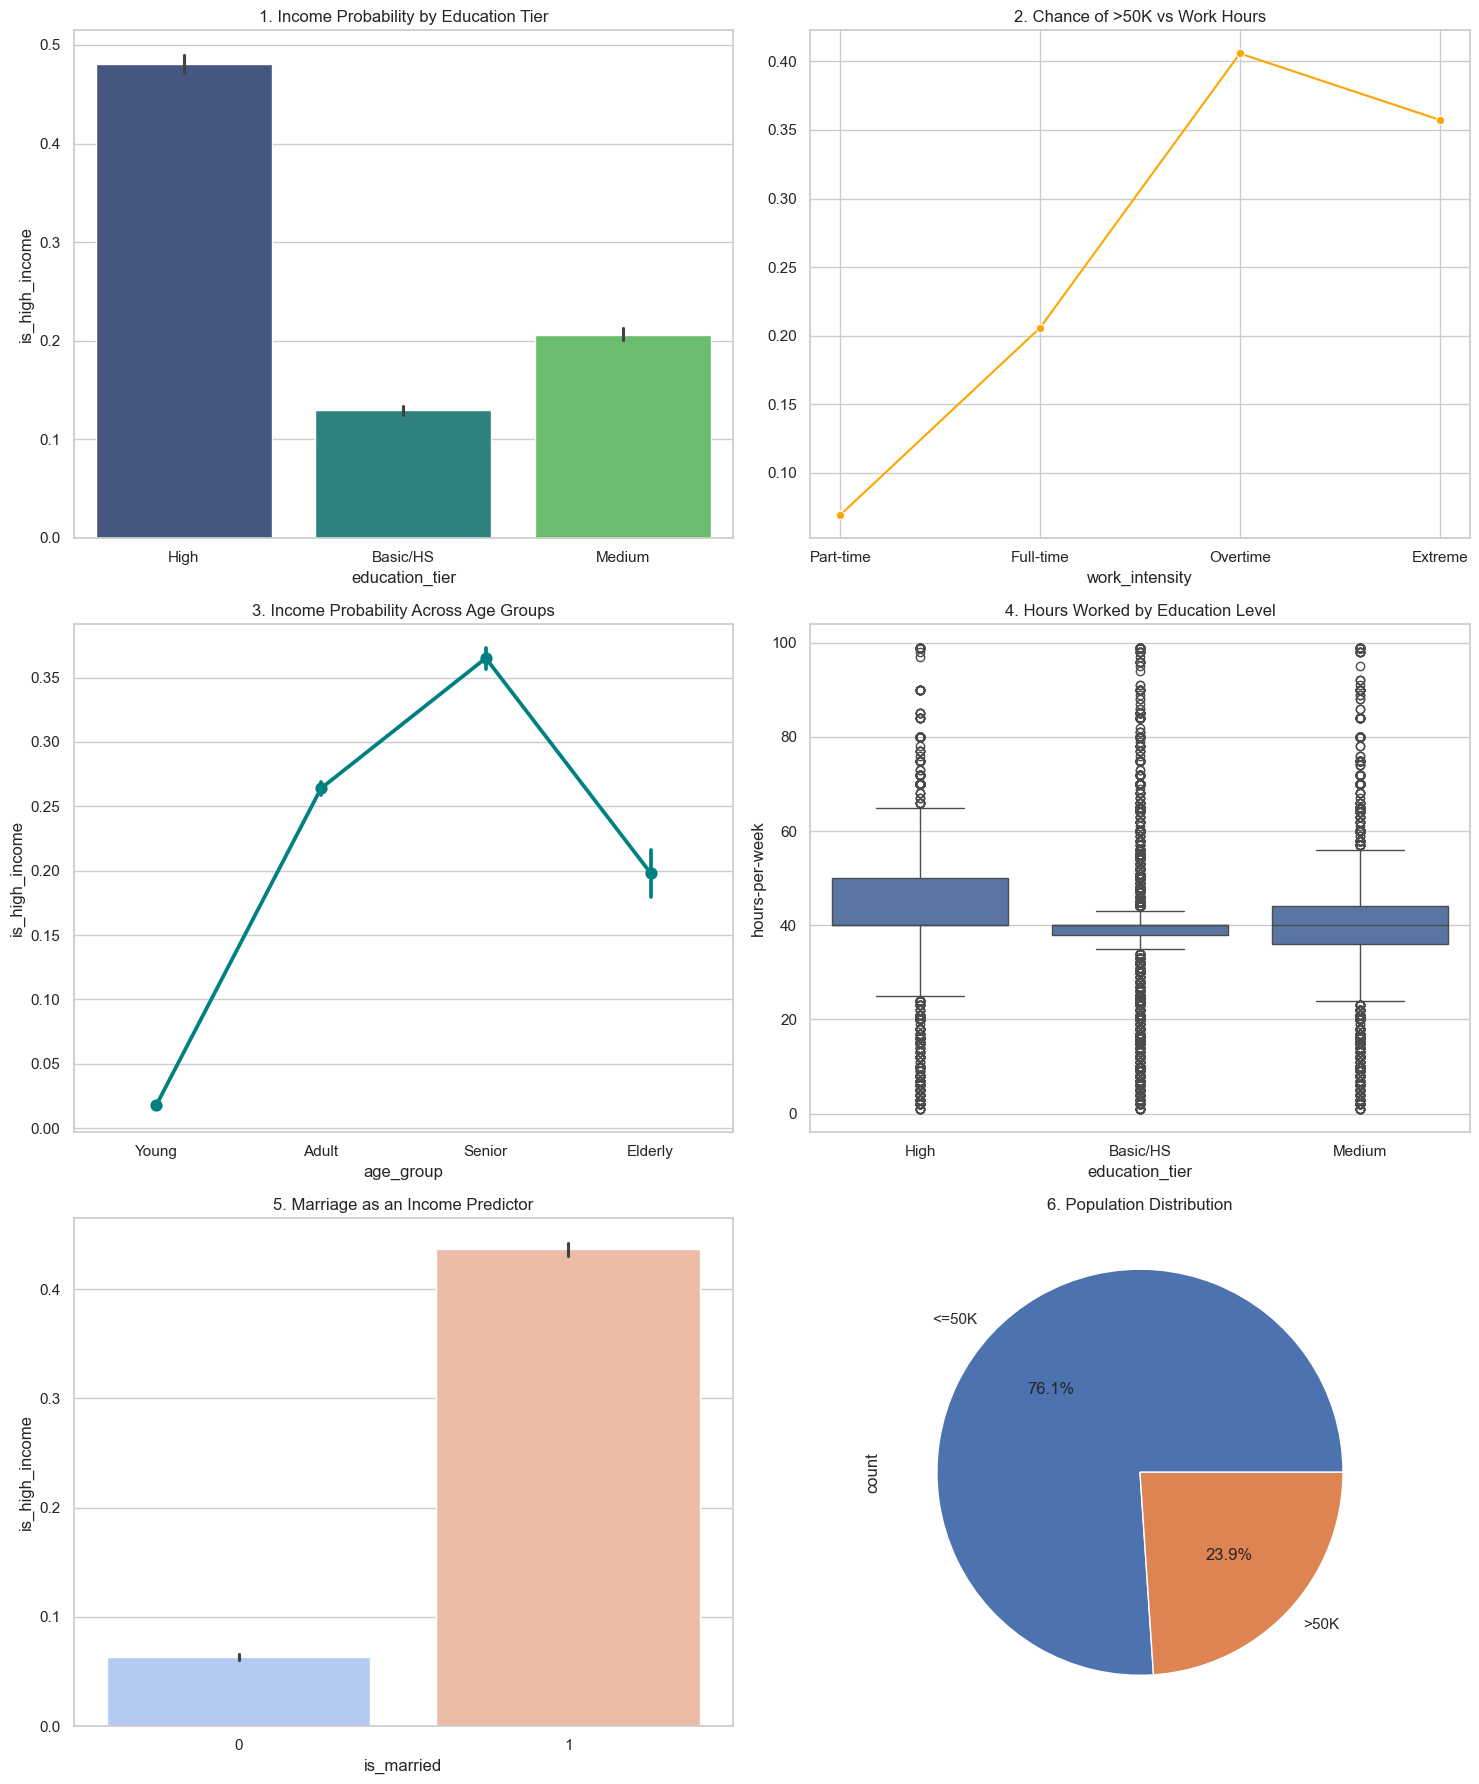

In [14]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# 1. The Education Premium
sns.barplot(ax=axes[0,0], x='education_tier', y='is_high_income', data=df_final, palette='viridis')
axes[0,0].set_title("1. Income Probability by Education Tier")

# 2. The Hustle Myth (Hours vs Income)
hustle = df_final.groupby('work_intensity')['is_high_income'].mean()
sns.lineplot(ax=axes[0,1], x=hustle.index, y=hustle.values, marker='o', color='orange')
axes[0,1].set_title("2. Chance of >50K vs Work Hours")

# 3. Life Cycle of Wealth
sns.pointplot(ax=axes[1,0], x='age_group', y='is_high_income', data=df_final, color='teal')
axes[1,0].set_title("3. Income Probability Across Age Groups")

# 4. Labor Commitment
sns.boxplot(ax=axes[1,1], x='education_tier', y='hours-per-week', data=df_final)
axes[1,1].set_title("4. Hours Worked by Education Level")

# 5. Marital Status Impact
df_final['is_married'] = df_final['marital-status'].str.contains('Married').astype(int)
sns.barplot(ax=axes[2,0], x='is_married', y='is_high_income', data=df_final, palette='coolwarm')
axes[2,0].set_title("5. Marriage as an Income Predictor")

# 6. Target Balance
df_final['is_high_income'].value_counts().plot.pie(ax=axes[2,1], autopct='%1.1f%%', labels=['<=50K', '>50K'])
axes[2,1].set_title("6. Population Distribution")

plt.tight_layout()
plt.show()

In [15]:
# Feature Selection
ml_features = ['age', 'hours-per-week', 'education_tier', 'work_intensity', 'age_group', 'is_married']
X = pd.get_dummies(df_final[ml_features], drop_first=True)
y = df_final['is_high_income']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))


--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      7375
           1       0.67      0.53      0.59      2388

    accuracy                           0.82      9763
   macro avg       0.76      0.72      0.74      9763
weighted avg       0.81      0.82      0.81      9763



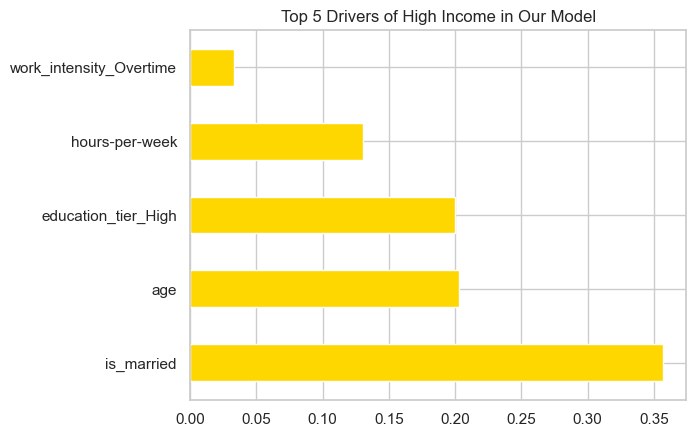

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='gold')
plt.title("Top 5 Drivers of High Income in Our Model")
plt.show()